# TPP Testing Notebook: Visual Analytics

This notebook is designed for **testing and understanding** the Thyrotoxic Periodic Paralysis (TPP) dataset and prediction outputs.

You will get:
- Data quality checks
- Multiple visualization views of vitals and events
- Prediction trend analysis
- Simple threshold-based test metrics

In [17]:
import importlib
import subprocess
import sys

def ensure_packages(packages):
    for package in packages:
        try:
            importlib.import_module(package)
        except ImportError:
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])

ensure_packages(['matplotlib', 'seaborn', 'plotly', 'nbformat', 'ipython'])

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = 'vscode'
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)
print('Libraries loaded successfully. Plotly renderer set to vscode (inline).')

Libraries loaded successfully. Plotly renderer set to vscode (inline).


## 1) Load Processed Data
This section loads both training features and prediction outputs, then combines them on user and timestamp for richer analysis.

In [2]:
from pathlib import Path

base = Path('.').resolve()
train_path = base / 'data' / 'processed' / 'training_data.csv'
pred_path = base / 'data' / 'processed' / 'predictions.csv'

train_df = pd.read_csv(train_path)
pred_df = pd.read_csv(pred_path)

train_df['timestamp'] = pd.to_datetime(train_df['timestamp'], utc=True, errors='coerce')
pred_df['timestamp'] = pd.to_datetime(pred_df['timestamp'], utc=True, errors='coerce')

full_df = pd.merge(
    train_df,
    pred_df,
    on=['user_id', 'timestamp'],
    how='left'
)

print('Training shape:', train_df.shape)
print('Predictions shape:', pred_df.shape)
print('Merged shape:', full_df.shape)
full_df.head()

Training shape: (240, 7)
Predictions shape: (240, 4)
Merged shape: (240, 9)


,timestamp,user_id,heart_rate,steps,activity_intensity,sleep_duration_minutes,event_severity,risk_prediction,risk_probability
0,2026-01-01 00:00:00+00:00,u1,72.000000,47,0.94,5.0,0,0,0.000775
1,2026-01-01 00:05:00+00:00,u1,72.251046,31,0.62,5.0,0,0,0.002184
2,2026-01-01 00:10:00+00:00,u1,72.502092,34,0.68,5.0,0,0,0.001867
3,2026-01-01 00:15:00+00:00,u1,72.753138,44,0.88,5.0,0,0,0.001542
4,2026-01-01 00:20:00+00:00,u1,73.004184,28,0.56,5.0,0,0,0.002591


## 2) Data Quality Test
Before interpreting model behavior, validate missing values, duplicates, and timeline consistency.

In [3]:
quality = pd.DataFrame({
    'column': full_df.columns,
    'missing_count': [full_df[c].isna().sum() for c in full_df.columns],
    'missing_pct': [round(100 * full_df[c].isna().mean(), 2) for c in full_df.columns],
    'dtype': [str(full_df[c].dtype) for c in full_df.columns]
})

dup_count = full_df.duplicated(subset=['user_id', 'timestamp']).sum()
time_range = (full_df['timestamp'].min(), full_df['timestamp'].max())

print('Duplicate user_id + timestamp rows:', dup_count)
print('Time range:', time_range[0], 'to', time_range[1])
quality.sort_values('missing_pct', ascending=False)

Duplicate user_id + timestamp rows: 0
Time range: 2026-01-01 00:00:00+00:00 to 2026-01-01 19:55:00+00:00


,column,missing_count,missing_pct,dtype
0,timestamp,0,0.0,"datetime64[us, UTC]"
1,user_id,0,0.0,str
2,heart_rate,0,0.0,float64
3,steps,0,0.0,int64
4,activity_intensity,0,0.0,float64
5,sleep_duration_minutes,0,0.0,float64
6,event_severity,0,0.0,int64
7,risk_prediction,0,0.0,int64
8,risk_probability,0,0.0,float64


## 3) Distribution Visualizations
These plots check whether feature values are in realistic ranges and whether event severity classes are balanced.

C:\Users\User\AppData\Local\Temp\ipykernel_25492\2096091539.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=full_df, x='event_severity', ax=axes[-1], palette='viridis')


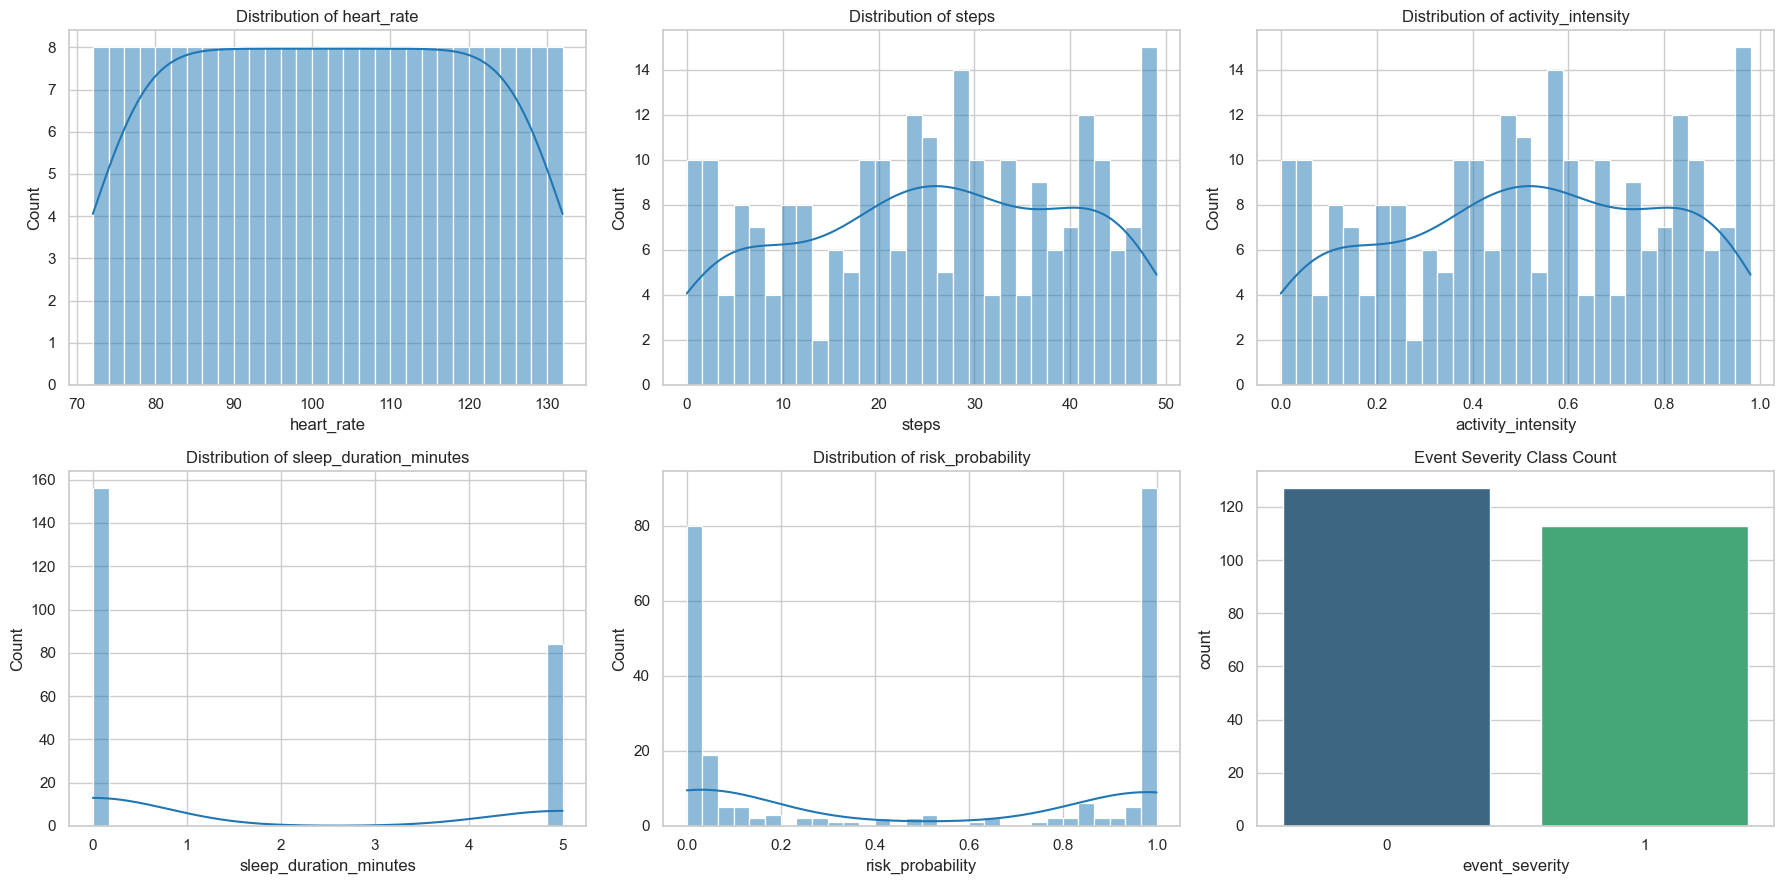

In [4]:
num_cols = ['heart_rate', 'steps', 'activity_intensity', 'sleep_duration_minutes', 'risk_probability']
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(full_df[col].dropna(), kde=True, bins=30, ax=axes[i], color='#1f77b4')
    axes[i].set_title(f'Distribution of {col}')

sns.countplot(data=full_df, x='event_severity', ax=axes[-1], palette='viridis')
axes[-1].set_title('Event Severity Class Count')
axes[-1].set_xlabel('event_severity')

plt.tight_layout()
plt.show()

## 4) Time-Series Behavior
Time plots reveal progression patterns that can indicate pre-event transitions.

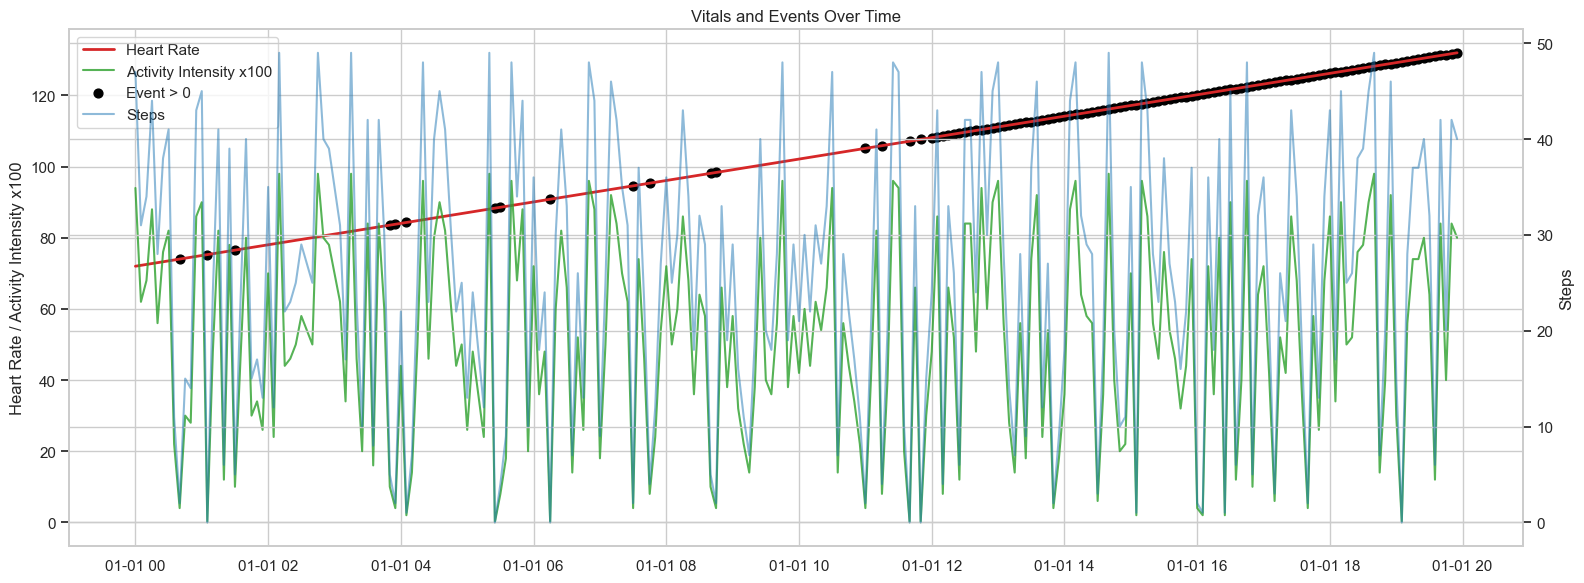

In [5]:
viz_df = full_df.sort_values('timestamp').copy()

fig, ax1 = plt.subplots(figsize=(16, 6))
ax2 = ax1.twinx()

ax1.plot(viz_df['timestamp'], viz_df['heart_rate'], label='Heart Rate', color='#d62728', linewidth=2)
ax1.plot(viz_df['timestamp'], viz_df['activity_intensity'] * 100, label='Activity Intensity x100', color='#2ca02c', alpha=0.8)
ax2.plot(viz_df['timestamp'], viz_df['steps'], label='Steps', color='#1f77b4', alpha=0.5)

event_rows = viz_df[viz_df['event_severity'] > 0]
ax1.scatter(event_rows['timestamp'], event_rows['heart_rate'], color='black', s=40, label='Event > 0')

ax1.set_title('Vitals and Events Over Time')
ax1.set_ylabel('Heart Rate / Activity Intensity x100')
ax2.set_ylabel('Steps')

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left')
plt.tight_layout()
plt.show()

## 5) Correlation Map
Correlation helps identify relationships among vital metrics, labels, and risk outputs.

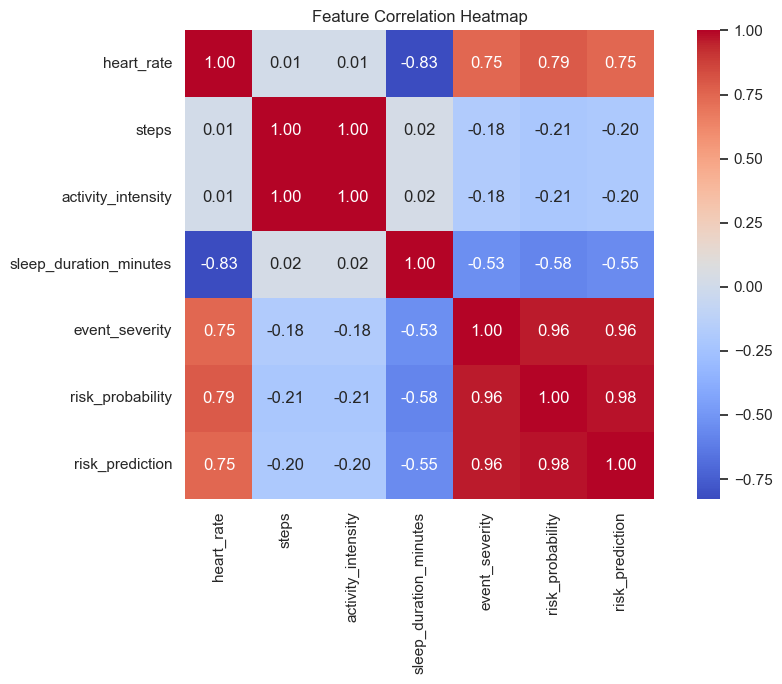

In [6]:
corr_cols = ['heart_rate', 'steps', 'activity_intensity', 'sleep_duration_minutes', 'event_severity', 'risk_probability', 'risk_prediction']
corr_df = full_df[corr_cols].copy()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## 6) Event-Focused Visualizations
This section compares vitals by event severity to inspect separation between normal and event windows.

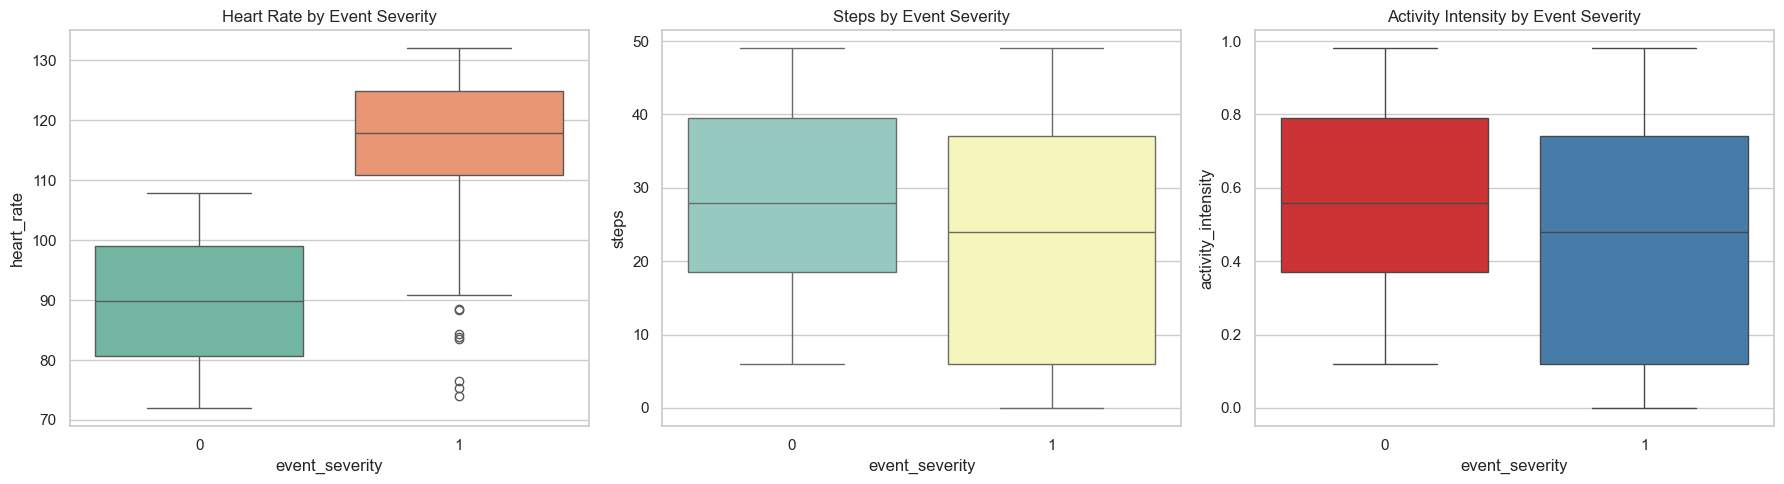

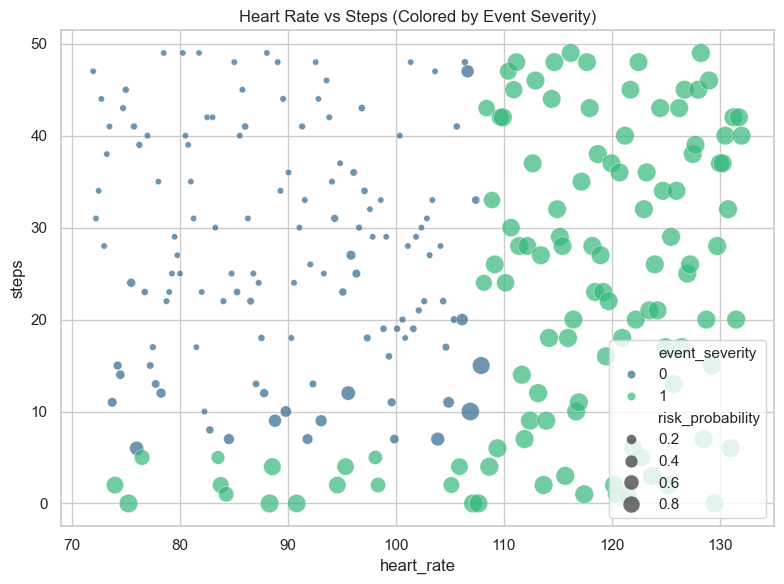

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(
    data=full_df,
    x='event_severity',
    y='heart_rate',
    hue='event_severity',
    legend=False,
    ax=axes[0],
    palette='Set2'
 )
axes[0].set_title('Heart Rate by Event Severity')

sns.boxplot(
    data=full_df,
    x='event_severity',
    y='steps',
    hue='event_severity',
    legend=False,
    ax=axes[1],
    palette='Set3'
 )
axes[1].set_title('Steps by Event Severity')

sns.boxplot(
    data=full_df,
    x='event_severity',
    y='activity_intensity',
    hue='event_severity',
    legend=False,
    ax=axes[2],
    palette='Set1'
 )
axes[2].set_title('Activity Intensity by Event Severity')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=full_df,
    x='heart_rate',
    y='steps',
    hue='event_severity',
    size='risk_probability',
    sizes=(20, 180),
    alpha=0.7,
    palette='viridis'
)
plt.title('Heart Rate vs Steps (Colored by Event Severity)')
plt.tight_layout()
plt.show()

## 7) Prediction Diagnostics and Threshold Test
This section visualizes probability behavior and evaluates a simple threshold rule against event labels.

Threshold: 0.5
Accuracy: 0.979
Precision: 0.966
Recall: 0.991
Confusion Matrix -> TP: 112, TN: 123, FP: 4, FN: 1


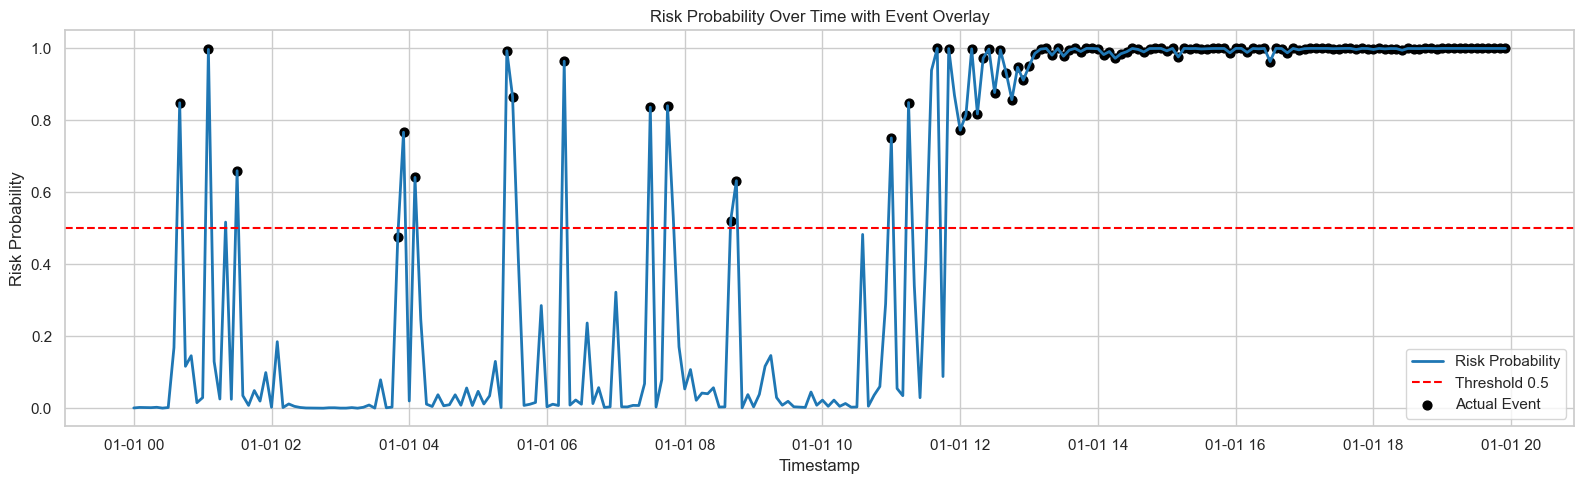

In [8]:
threshold = 0.5
eval_df = full_df.dropna(subset=['risk_probability', 'event_severity']).copy()
eval_df['actual_event'] = (eval_df['event_severity'] > 0).astype(int)
eval_df['predicted_event_by_threshold'] = (eval_df['risk_probability'] >= threshold).astype(int)

tp = int(((eval_df['actual_event'] == 1) & (eval_df['predicted_event_by_threshold'] == 1)).sum())
tn = int(((eval_df['actual_event'] == 0) & (eval_df['predicted_event_by_threshold'] == 0)).sum())
fp = int(((eval_df['actual_event'] == 0) & (eval_df['predicted_event_by_threshold'] == 1)).sum())
fn = int(((eval_df['actual_event'] == 1) & (eval_df['predicted_event_by_threshold'] == 0)).sum())

accuracy = (tp + tn) / max(tp + tn + fp + fn, 1)
precision = tp / max(tp + fp, 1)
recall = tp / max(tp + fn, 1)

print(f'Threshold: {threshold}')
print(f'Accuracy: {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'Confusion Matrix -> TP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}')

plt.figure(figsize=(16, 5))
plt.plot(eval_df['timestamp'], eval_df['risk_probability'], color='#1f77b4', linewidth=2, label='Risk Probability')
plt.axhline(threshold, color='red', linestyle='--', label=f'Threshold {threshold}')

event_points = eval_df[eval_df['actual_event'] == 1]
plt.scatter(event_points['timestamp'], event_points['risk_probability'], color='black', s=40, label='Actual Event')

plt.title('Risk Probability Over Time with Event Overlay')
plt.xlabel('Timestamp')
plt.ylabel('Risk Probability')
plt.legend()
plt.tight_layout()
plt.show()

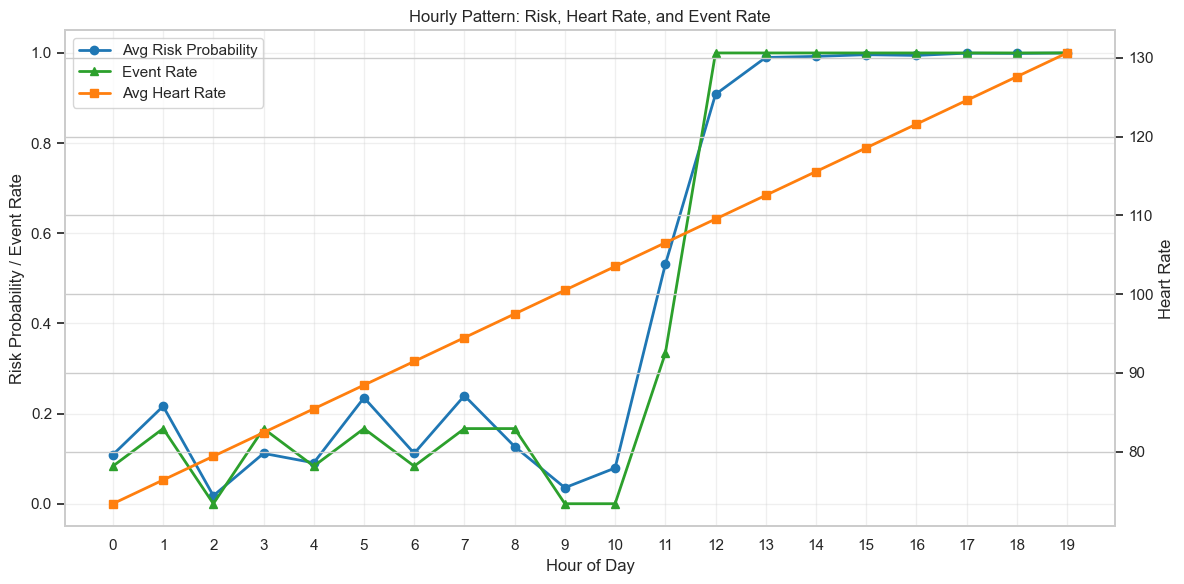

In [20]:
hourly = eval_df.copy()
hourly['hour'] = hourly['timestamp'].dt.hour
hourly_summary = hourly.groupby('hour', as_index=False).agg(
    avg_risk_probability=('risk_probability', 'mean'),
    avg_heart_rate=('heart_rate', 'mean'),
    event_rate=('actual_event', 'mean')
)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

ax1.plot(
    hourly_summary['hour'],
    hourly_summary['avg_risk_probability'],
    marker='o',
    linewidth=2,
    color='#1f77b4',
    label='Avg Risk Probability'
)
ax1.plot(
    hourly_summary['hour'],
    hourly_summary['event_rate'],
    marker='^',
    linewidth=2,
    color='#2ca02c',
    label='Event Rate'
)

ax2.plot(
    hourly_summary['hour'],
    hourly_summary['avg_heart_rate'],
    marker='s',
    linewidth=2,
    color='#ff7f0e',
    label='Avg Heart Rate'
)

ax1.set_title('Hourly Pattern: Risk, Heart Rate, and Event Rate')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Risk Probability / Event Rate')
ax2.set_ylabel('Heart Rate')
ax1.set_xticks(sorted(hourly_summary['hour'].unique()))
ax1.grid(alpha=0.3)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left')

plt.tight_layout()
plt.show()

## 8) Interpretation Guide
How to read the outputs:
- **Sharp spikes in risk probability** near event points suggest the model is sensitive to pre-event patterns.
- **Distribution and box plots** help verify if event periods differ from baseline periods.
- **Correlation heatmap** helps identify potentially redundant or highly coupled features.
- **Threshold metrics** are a quick test, not a full validation protocol. For production, use cross-validation, ROC/PR analysis, and calibration.

You can now tune thresholds and compare behavior across users if multi-user data is available.